# Supplementary Material
**PICU-FE Dataset (Zenodo Record 20475499)**
*   **Author**: Vicente Mir Cerezo et al.
*   **Version**: 2.0.
*   **Description**: This notebook provides the complete reproducible pipeline for the PICU-FE dataset. It executes all analytical steps including clinical data quality optimization, temporal trend analysis, and machine learning benchmarking directly from the accompanying CSV file.



# 0. Environment Setup

In [ ]:
from __future__ import annotations

import io
import logging
import os
import warnings
from importlib.util import find_spec
from typing import List

# ======================================================================
# DEPENDENCY CHECK
# ======================================================================
_REQUIRED = {
    "pandas": "pandas",
    "numpy": "numpy",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scikit-learn": "sklearn",
    "imbalanced-learn": "imblearn",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "requests": "requests",
    "joblib": "joblib",
    "ipython": "IPython"
}

missing = [pkg for pkg, mod in _REQUIRED.items() if find_spec(mod) is None]
if missing:
    raise ImportError(
        f"Missing packages: {', '.join(missing)}\n"
        "Please install dependencies by running: pip install -r code/requirements.txt"
    )

# ======================================================================
# CORE & UTILS
# ======================================================================
import numpy as np
import pandas as pd
import requests
from joblib import Parallel, delayed

# ======================================================================
# STATISTICS
# ======================================================================
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, rankdata

# ---------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import Image, display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ======================================================================
# MACHINE LEARNING
# ======================================================================
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import average_precision_score, make_scorer, precision_recall_curve, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# ======================================================================
# GLOBAL CONFIGURATION
# ======================================================================
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(message)s")

# 1. Dataset Loading


In [2]:
TOKEN = "uEm4IP8MYnaOchnSsKo4R7dsH79p8wtMjmL9UOooX7KnLsTTD53c4aZvlNJu"
URL = "https://zenodo.org/api/records/20475499"

try:
    headers = {"Authorization": f"Bearer {TOKEN}"}
    response = requests.get(URL, headers=headers)
    response.raise_for_status()

    file_url = response.json()["files"][0]["links"]["self"]

    # Load dataset PICU-FE as df
    df = pd.read_csv(file_url, storage_options=headers)

    # Display dimensions and preview
    print(f"Dataset loaded: {df.shape[0]:,} rows and {df.shape[1]} columns.")
    display(df.head())

except requests.exceptions.RequestException as e:
    print(f"Connection Error: {e}")
except Exception as e:
    print(f"Parsing Error: {e}")

Dataset loaded: 1,155,211 rows and 13 columns.


,ID,HOUR,HR,RR,SPO2,TEMP,DBP,MBP,SBP,IS_INVASIVE,AGE,SEX,OUTCOME
0,3206,2011 00:00,127.0,23.0,98.0,NaN,45.00,58.50,90.25,True,0.0,male,survived
1,3206,2011 01:00,124.0,24.0,96.0,NaN,49.50,67.50,100.50,True,0.0,male,survived
2,3206,2011 02:00,124.0,24.0,96.0,NaN,44.00,57.25,89.00,True,0.0,male,survived
3,3206,2011 03:00,128.0,24.0,97.0,NaN,49.50,66.50,98.00,True,0.0,male,survived
4,3206,2011 04:00,130.0,28.0,97.0,NaN,47.25,60.50,93.25,True,0.0,male,survived


# 2. Baseline Cohort Characterization
This section establishes the primary cohort size and target prevalence (mortality) before applying quality-driven filtering steps.

In [3]:
# ======================================================================
# BASIC STATISTICS
# ======================================================================

def generate_scientific_report(df: pd.DataFrame, id_col: str = 'ID', outcome_col: str = 'OUTCOME') -> None:
    print("1. Dataset shape")
    print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}\n")

    print("2. Descriptive statistics")

    # Safe formatting helpers
    def _fmt_num(val) -> str:
        if pd.isna(val):
            return "-"
        try:
            v_float = float(val)
            return str(int(v_float)) if v_float.is_integer() else f"{v_float:.4f}".rstrip('0').rstrip('.')
        except (ValueError, TypeError):
            return str(val)

    def _fmt_cat(val) -> str:
        if pd.isna(val):
            return "-"
        try:
            v_float = float(val)
            if v_float.is_integer():
                return str(int(v_float))
        except (ValueError, TypeError):
            pass
        return str(val)

    # Numeric features
    num_df = df.select_dtypes(include=['number']).drop(columns=[id_col], errors='ignore')
    if not num_df.empty:
        print("\nNumeric features")
        print(num_df.describe().T.apply(lambda c: c.map(_fmt_num)).to_markdown())

    # Categorical features
    cat_df = df.select_dtypes(exclude=['number', 'datetime', 'datetimetz'])
    if not cat_df.empty:
        print("\nCategorical features")
        print(cat_df.describe().T.apply(lambda c: c.map(_fmt_cat)).to_markdown())

    print("\n3. Mortality rate (OUTCOME)")

    if outcome_col in df.columns:
        # Observation-level stats (Total rows)
        obs_counts = df[outcome_col].value_counts(dropna=False)
        obs_rates = df[outcome_col].value_counts(dropna=False, normalize=True) * 100

        # Episode/Patient-level stats (Deduplicated)
        df_ep = df.drop_duplicates(subset=[id_col]) if id_col in df.columns else df
        ep_counts = df_ep[outcome_col].value_counts(dropna=False)
        ep_rates = df_ep[outcome_col].value_counts(dropna=False, normalize=True) * 100

        # Build output table
        mortality = pd.DataFrame(index=ep_counts.index)
        mortality.index.name = outcome_col.upper()

        mortality['Count: Episode (Row)'] = [
            f"{int(ep_counts.get(idx, 0))} ({int(obs_counts.get(idx, 0))})"
            for idx in mortality.index
        ]

        mortality['Rate: Episode (Row)'] = [
            f"{ep_rates.get(idx, 0):.2f}% ({obs_rates.get(idx, 0):.2f}%)"
            for idx in mortality.index
        ]

        print(mortality.to_markdown())

# ======================================================================
# EXECUTION
# ======================================================================
generate_scientific_report(df, id_col='ID', outcome_col='OUTCOME')

1. Dataset shape
Rows: 1155211 | Columns: 13

2. Descriptive statistics

Numeric features
|      |   count |     mean |     std |   min |   25% |   50% |    75% |    max |
|:-----|--------:|---------:|--------:|------:|------:|------:|-------:|-------:|
| HR   | 1155185 | 122.327  | 28.3364 |     0 | 103   | 123   | 142    |  600   |
| RR   | 1127636 |  30.8965 | 22.808  |   -19 |  21   |  28   |  36    | 9873   |
| SPO2 | 1141354 |  95.8832 |  4.8789 |     0 |  95   |  97   |  99    |  100   |
| TEMP |   15643 |  36.2966 |  1.0785 |     0 |  36   |  36.4 |  36.8  |   42   |
| DBP  |  941636 |  57.3347 | 23.6914 |   -38 |  47   |  56   |  66    | 7441   |
| MBP  |  972516 |  69.9036 | 29.6677 |   -39 |  58   |  68   |  79    | 8650   |
| SBP  |  941278 |  96.9813 | 20.2442 |    -7 |  84.5 |  97   | 109.25 | 4619.5 |
| AGE  | 1146886 |   3.3911 |  4.4858 |     0 |   0   |   1   |   6    |   16   |

Categorical features
|             |   count |   unique | top        |    freq |
|:------

# 3. Methods

## 3.1 Data processing

Raw EHR data contains artifacts (sensor errors, manual entry mistakes) that can bias predictive models. This section implements a filtering pipeline:

*   **Stage 1: Physiological Plausibility**: Masks values that are physically impossible (e.g., negative SpO2) or physiological implausible based on pediatric norms (Mehta et al., 2024).
*   **Stage 2: Global Sparsity**: Removes variables that have more than 50% missing data across the entire cohort, as they lack sufficient signal for reliable learning.
*   **Stage 3: Episode Trimming**: Ensures each patient stay (episode) has at least 6 hours of data. Additionally, a quality filter is applied to exclude episodes with a recording density below 50% or temporal gaps exceeding 6 hours, ensuring sufficient signal for temporal trend analysis.

In [4]:
# ======================================================================
# PREPROCESSING CONFIGURATION
# ======================================================================

ID_COL     = "ID"
TIME_COL   = "HOUR"
TARGET_COL = "OUTCOME"
AGE_COL    = "AGE"

MAX_GLOBAL_MISSING    = 0.50
MAX_GAP_HOURS         = 6.0
MIN_SUFFIX_DENSITY     = 0.50
MIN_HOURS_PER_EPISODE  = 6.0
SMD_SHIFT_THRESHOLD   = 0.10

# Physiologically Impossible Values (PIVs): absolute limits only
ABSOLUTE_LIMITS = {
    "HR":   (0, 300),
    "RR":   (0, 150),
    "SBP":  (0, 300),
    "DBP":  (0, 200),
    "MBP":  (0, 220),
    "TEMP": (0, 42),
}

# ======================================================================
# 1. HELPER FUNCTIONS
# ======================================================================

def parse_custom_hour(series: pd.Series) -> np.ndarray:
    def _parse(v):
        try:
            s = str(v).strip().split()[-1].split(':')
            return float(s[0]) + (float(s[1]) / 60.0 if len(s) > 1 else 0.0)
        except:
            return np.nan
    return np.array([_parse(x) for x in series], dtype=np.float32)

def encode_outcome(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)

    counts = series.dropna().value_counts(ascending=True)
    if counts.empty:
        return pd.Series(np.nan, index=series.index)

    target_class = counts.index[0]
    encoded = np.where(series.isna(), np.nan, np.where(series == target_class, 1.0, 0.0))
    return pd.Series(encoded, index=series.index)

def fmt_p(p: float) -> str:
    return "---" if pd.isna(p) else (f"{p:.2e}" if p < 1e-3 else f"{p:.4f}")

def _smd_cont(pre: pd.Series, post: pd.Series) -> float:
    pre, post = pre.dropna(), post.dropna()
    if len(pre) < 2 or len(post) < 2:
        return np.nan
    pooled = np.sqrt(((len(pre) - 1) * pre.var() + (len(post) - 1) * post.var()) / (len(pre) + len(post) - 2))
    return abs(pre.mean() - post.mean()) / pooled if pooled > 0 else np.nan

def _smd_cat(pre: pd.Series, post: pd.Series) -> float:
    pre, post = pre.dropna().astype(str), post.dropna().astype(str)
    if pre.empty or post.empty:
        return np.nan
    cats = list(set(pre.unique()) | set(post.unique()))
    p1 = pre.value_counts(normalize=True).reindex(cats, fill_value=0).to_numpy()
    p2 = post.value_counts(normalize=True).reindex(cats, fill_value=0).to_numpy()
    pm = (p1 + p2) / 2
    return float(np.sqrt(np.sum(((p1 - p2) ** 2) / (pm + 1e-12))) / np.sqrt(2))

def _pval_cont(pre: pd.Series, post: pd.Series) -> float:
    pre, post = pre.dropna(), post.dropna()
    return mannwhitneyu(pre, post, alternative="two-sided").pvalue if len(pre) > 1 and len(post) > 1 else np.nan

def _pval_cat(pre: pd.Series, post: pd.Series) -> float:
    pre, post = pre.dropna().astype(str), post.dropna().astype(str)
    cats = list(set(pre.unique()) | set(post.unique()))
    if len(cats) < 2:
        return np.nan
    tbl = np.vstack([
        pre.value_counts().reindex(cats, fill_value=0).to_numpy(),
        post.value_counts().reindex(cats, fill_value=0).to_numpy()
    ])
    try:
        return chi2_contingency(tbl)[1]
    except Exception:
        return np.nan

# ======================================================================
# 2. FILTERING PIPELINE
# ======================================================================

def run_preprocessing(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 79)
    print("PREPROCESSING")
    print("=" * 79)

    df_work = df.copy()

    cat_cols = [c for c in df.columns if c not in {ID_COL, TIME_COL} and (df[c].dtype == object or df[c].nunique() <= 3)]
    cont_cols = [c for c in df.columns if c not in cat_cols and c not in {ID_COL, TIME_COL}]

    if TARGET_COL in df_work.columns:
        df_work["_ORIG_TARGET"] = df_work[TARGET_COL]
        df_work[TARGET_COL] = encode_outcome(df_work[TARGET_COL])

    for col in cont_cols:
        if col in df_work.columns:
            df_work[col] = pd.to_numeric(df_work[col], errors="coerce")

    print("\n1. Physiological Plausibility Check (PIV Audit):")
    audit_piv = {}

    # 1A. Apply absolute limits
    for col, (lo, hi) in ABSOLUTE_LIMITS.items():
        if col in df_work.columns:
            mask = (df_work[col] < lo) | (df_work[col] > hi)
            if mask.any():
                audit_piv[col] = int(mask.sum())
                df_work.loc[mask, col] = np.nan

    # 1B. Apply relational physiological constraint: DBP < SBP
    if "DBP" in df_work.columns and "SBP" in df_work.columns:
        invalid_bp = (
            df_work["DBP"].notna() &
            df_work["SBP"].notna() &
            (df_work["DBP"] >= df_work["SBP"])
        )
        if invalid_bp.any():
            audit_piv["DBP>=SBP"] = int(invalid_bp.sum())
            df_work.loc[invalid_bp, ["DBP", "SBP"]] = np.nan

    if audit_piv:
        for k, v in audit_piv.items():
            print(f"   • {k}: {v:,} records masked (→ NaN)")
    else:
        print("   • No implausible records detected.")
    print(f"   ► Total PIV-masked records: {sum(audit_piv.values()):,}")

    print("\n2. Sparsity Filter (threshold: >50% missing):")
    present_dyn = [c for c in cont_cols if c != AGE_COL and c in df_work.columns]
    sparsity = df_work[present_dyn].isna().mean() if present_dyn else pd.Series(dtype=float)
    kept_dyn = [c for c in present_dyn if sparsity[c] <= MAX_GLOBAL_MISSING]
    dropped = list(set(present_dyn) - set(kept_dyn))

    df_work.drop(columns=dropped, inplace=True)
    print(f"   • Dropped features: {dropped if dropped else 'None'}")

    df_work["_REL_HOURS"] = parse_custom_hour(df_work[TIME_COL])

    if kept_dyn:
        df_work["_has_vital"] = df_work[kept_dyn].notna().to_numpy().any(axis=1)

        bounds = df_work[df_work["_has_vital"]].groupby(ID_COL)["_REL_HOURS"].agg(["min", "max"])
        bounds["span"] = bounds["max"] - bounds["min"]

        df_work = df_work.join(bounds, on=ID_COL)
        mask_time = (df_work["_REL_HOURS"] >= df_work["min"]) & (df_work["_REL_HOURS"] <= df_work["max"])
        df_trimmed = df_work[mask_time].copy()

        df_trimmed = df_trimmed[df_trimmed["span"] >= MIN_HOURS_PER_EPISODE]

        density = df_trimmed.groupby(ID_COL)["_has_vital"].mean()
        valid_ids = density[density >= MIN_SUFFIX_DENSITY].index
        df_trimmed = df_trimmed[df_trimmed[ID_COL].isin(valid_ids)]

        df_trimmed.drop(columns=["_has_vital", "min", "max", "span"], errors="ignore", inplace=True)
    else:
        df_trimmed = pd.DataFrame(columns=df_work.columns)

    is_monotonic = df_trimmed.groupby(ID_COL)["_REL_HOURS"].apply(lambda x: x.is_monotonic_increasing).all() if not df_trimmed.empty else True

    print("\n3. Dataset Overview:")
    print(f"   • Total observations:       {len(df):>10,} → {len(df_trimmed):>10,}")
    print(f"   • Unique clinical episodes: {df[ID_COL].nunique():>10,} → {df_trimmed[ID_COL].nunique():>10,}")
    print(f"   • Temporal integrity:       {'PASSED' if is_monotonic else 'FAILED'}")

    y_pre = df_work.groupby(ID_COL)[TARGET_COL].first().dropna() if TARGET_COL in df_work.columns else pd.Series(dtype=float)
    y_post = df_trimmed.groupby(ID_COL)[TARGET_COL].first().dropna() if TARGET_COL in df_trimmed.columns else pd.Series(dtype=float)

    mortality_pre = y_pre.mean() * 100 if not y_pre.empty else 0.0
    mortality_post = y_post.mean() * 100 if not y_post.empty else 0.0
    outcome_smd = _smd_cont(y_pre, y_post)
    status_smd = "WARNING" if pd.notna(outcome_smd) and outcome_smd >= SMD_SHIFT_THRESHOLD else "OK"

    print("\n4. Outcome Distribution & Bias Audit:")
    print(f"   • Pre-curation target rate: {mortality_pre:.2f}%")
    print(f"   • Post-curation target rate:{mortality_post:.2f}%")
    print(f"   • Outcome SMD:              {outcome_smd:.4f} ({status_smd})")

    print("\n5. TABLE 3: Comparative Analysis of Cohort Characteristics Pre- and Post-Filtering:")

    pre_cat_agg = df_work.groupby(ID_COL)[[c for c in cat_cols if c in df_work.columns]].first()
    post_cat_agg = df_trimmed.groupby(ID_COL)[[c for c in cat_cols if c in df_trimmed.columns]].first()
    pre_cont_agg = df_work.groupby(ID_COL)[[c for c in cont_cols if c in df_work.columns]].mean()
    post_cont_agg = df_trimmed.groupby(ID_COL)[[c for c in cont_cols if c in df_trimmed.columns]].mean()

    audit_rows = []
    for col in df.columns:
        if col in {ID_COL, TIME_COL}:
            continue

        is_cat = col in cat_cols
        post_exists = col in df_trimmed.columns

        pre_series = df_work[col] if col in df_work.columns else df[col]
        miss_pre = pre_series.isna().mean() * 100

        if post_exists:
            pre_dist = pre_cat_agg[col] if is_cat else pre_cont_agg[col]
            post_dist = post_cat_agg[col] if is_cat else post_cont_agg[col]

            smd = _smd_cat(pre_dist, post_dist) if is_cat else _smd_cont(pre_dist, post_dist)
            pval = _pval_cat(pre_dist, post_dist) if is_cat else _pval_cont(pre_dist, post_dist)
            miss_post = df_trimmed[col].isna().mean() * 100

            miss_post_txt = f"{miss_post:.2f}"
            delta_txt = f"{miss_post - miss_pre:+.2f}"
            status_txt = "❌ SHIFT" if pd.notna(smd) and smd >= SMD_SHIFT_THRESHOLD else "✅ PASS"
        else:
            smd, pval = np.nan, np.nan
            miss_post_txt = "Removed"
            delta_txt = "---"
            status_txt = "✅ PASS"

        audit_rows.append({
            "Variable":       col,
            "Type":           "Cat" if is_cat else "Cont",
            "SMD":            f"{smd:.4f}" if pd.notna(smd) else "---",
            "p-value":        fmt_p(pval),
            "Miss. Pre (%)":  f"{miss_pre:.2f}",
            "Miss. Post (%)": miss_post_txt,
            "Δ Miss. (%)":    delta_txt,
            "Status":         status_txt,
        })

    print(pd.DataFrame(audit_rows).to_string(index=False))
    print("=" * 79)

    df_trimmed.drop(columns=["_REL_HOURS", TARGET_COL, "_has_vital", "min", "max", "span"], errors="ignore", inplace=True)
    if "_ORIG_TARGET" in df_trimmed.columns:
        df_trimmed.rename(columns={"_ORIG_TARGET": TARGET_COL}, inplace=True)

    return df_trimmed[[c for c in df.columns if c in df_trimmed.columns]].copy()

# ======================================================================
# EXECUTION
# ======================================================================
df_final = run_preprocessing(df)

PREPROCESSING

1. Physiological Plausibility Check (PIV Audit):
   • HR: 19 records masked (→ NaN)
   • RR: 24 records masked (→ NaN)
   • SBP: 12 records masked (→ NaN)
   • DBP: 145 records masked (→ NaN)
   • MBP: 340 records masked (→ NaN)
   • DBP>=SBP: 17,995 records masked (→ NaN)
   ► Total PIV-masked records: 18,535

2. Sparsity Filter (threshold: >50% missing):
   • Dropped features: ['TEMP']

3. Dataset Overview:
   • Total observations:        1,155,211 →  1,151,836
   • Unique clinical episodes:     12,910 →     12,014
   • Temporal integrity:       PASSED

4. Outcome Distribution & Bias Audit:
   • Pre-curation target rate: 1.39%
   • Post-curation target rate:1.37%
   • Outcome SMD:              0.0018 (OK)

5. TABLE 3: Comparative Analysis of Cohort Characteristics Pre- and Post-Filtering:
   Variable Type    SMD p-value Miss. Pre (%) Miss. Post (%) Δ Miss. (%) Status
         HR Cont 0.0113  0.4432          0.00           0.00       -0.00 ✅ PASS
         RR Cont 0.0001

# 4. Technical Validaton

## 4.1 Statistical Summary
This procedure generates a descriptive summary of the validated cohort. It automatically detects distribution skewness to report variables as Mean ± SD or Median [IQR] and calculates global data density metrics (observations per clinical episode).

In [5]:
# ======================================================================
# COHORT CHARACTERISTICS
# ======================================================================

# Unit mapping
units = {
    "HR": "bpm", "RR": "rpm", "SPO2": "%", "TEMP": "°C",
    "DBP": "mmHg", "MAP": "mmHg", "SBP": "mmHg", "AGE": "years",
    "HOUR": "hours"
}

def generate_scientific_report(df: pd.DataFrame, unit_map: dict = None) -> pd.DataFrame:
    unit_map = unit_map or {}
    table_rows = []
    has_id = "ID" in df.columns

    # Cohort Density Metrics
    if has_id and not df.empty:
        obs_per_ep = df["ID"].value_counts()

        print(f"\n{'='*30} COHORT DENSITY METRICS {'='*30}")
        print(f"• Unique Clinical Episodes: {len(obs_per_ep):,}")
        print(f"• Total Observations:       {len(df):,}")
        print(f"• Global Sparsity:          {df.isna().values.mean() * 100:.2f}%")
        print(f"{'='*84}\n")

    # Cross-sectional dataset for non-time-varying features
    df_unique = df.drop_duplicates(subset=["ID"]) if has_id else df
    missing_pct_total = df.isna().mean() * 100
    missing_pct_unique = df_unique.isna().mean() * 100

    if has_id:
        table_rows.append({
            "Variable": "ID", "Missing (%)": "–",
            "Summary Statistic": f"{len(obs_per_ep):,} unique",
            "Reported Metric": "Count", "Distribution": "–", "Observed Range": "–"
        })

    # Auto-detect data types (excluding ID and HOUR explicitly)
    ignore_cols = {"ID", "HOUR"}
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in ignore_cols]
    categorical_cols = [c for c in df.select_dtypes(exclude=[np.number]).columns if c not in ignore_cols]

    # Force HOUR to be evaluated into the table
    continuous_queue = numeric_cols + (["HOUR"] if "HOUR" in df.columns else [])

    # Continuous variables evaluation
    for col in continuous_queue:
        # Tratamiento especial para HOUR basado en la longitud de episodios (1 fila = 1 hora)
        if col == "HOUR" and has_id:
            series = obs_per_ep
            summary = f"{series.median():.1f} [{series.quantile(0.25):.1f}–{series.quantile(0.75):.1f}]"
            obs_range = f"{series.min()}–{series.max()} {unit_map.get(col, 'hours')}".strip()

            table_rows.append({
                "Variable": col, "Missing (%)": "–",
                "Summary Statistic": summary, "Reported Metric": "Median [IQR]",
                "Distribution": "Hours / Episode", "Observed Range": obs_range
            })
            continue

        # Tratamiento estándar para el resto de variables
        is_cross_sectional = (col.upper() == "AGE")
        series = df_unique[col].dropna() if is_cross_sectional else df[col].dropna()
        missing_pct = missing_pct_unique[col] if is_cross_sectional else missing_pct_total[col]

        if series.empty:
            continue

        sk = series.skew()
        is_normal = pd.notna(sk) and abs(sk) < 1.0

        if is_normal:
            summary, metric, distrib = f"{series.mean():.2f} ± {series.std():.2f}", "Mean ± SD", "Normal"
        else:
            summary, metric, distrib = f"{series.median():.2f} [{series.quantile(0.25):.2f}–{series.quantile(0.75):.2f}]", "Median [IQR]", f"Skewed ({sk:.2f})" if pd.notna(sk) else "–"

        obs_range = f"{series.min():.1f}–{series.max():.1f} {unit_map.get(col, '')}".strip()

        table_rows.append({
            "Variable": col, "Missing (%)": f"{missing_pct:.2f}" if missing_pct > 0 else "–",
            "Summary Statistic": summary, "Reported Metric": metric,
            "Distribution": distrib, "Observed Range": obs_range
        })

    # Categorical variables evaluation
    for cat in categorical_cols:
        missing_pct = missing_pct_unique[cat]
        val_counts = df_unique[cat].value_counts(normalize=True) * 100
        cat_str = " / ".join([f"{v:.2f}% ({k})" for k, v in val_counts.items()])

        table_rows.append({
            "Variable": cat.upper(), "Missing (%)": f"{missing_pct:.2f}" if missing_pct > 0 else "–",
            "Summary Statistic": cat_str, "Reported Metric": "Percentage",
            "Distribution": "Categorical", "Observed Range": "–"
        })

    return pd.DataFrame(table_rows)

# ======================================================================
# EXECUTE
# ======================================================================
scientific_table1 = generate_scientific_report(df_final, units)

print("TABLE 4: Cohort Characteristics and Data Quality Audit")
print(scientific_table1.to_markdown(index=False))


============================== COHORT DENSITY METRICS ==============================
• Unique Clinical Episodes: 12,014
• Total Observations:       1,151,836
• Global Sparsity:          5.21%

TABLE 4: Cohort Characteristics and Data Quality Audit
| Variable    | Missing (%)   | Summary Statistic                                     | Reported Metric   | Distribution    | Observed Range   |
|:------------|:--------------|:------------------------------------------------------|:------------------|:----------------|:-----------------|
| ID          | –             | 12,014 unique                                         | Count             | –               | –                |
| HR          | 0.00          | 122.34 ± 28.29                                        | Mean ± SD         | Normal          | 0.0–300.0 bpm    |
| RR          | 2.39          | 28.00 [21.00–36.00]                                   | Median [IQR]      | Skewed (2.20)   | 0.0–140.0 rpm    |
| SPO2        | 1.19      

## 4.2 Characteristics and Data Distribution

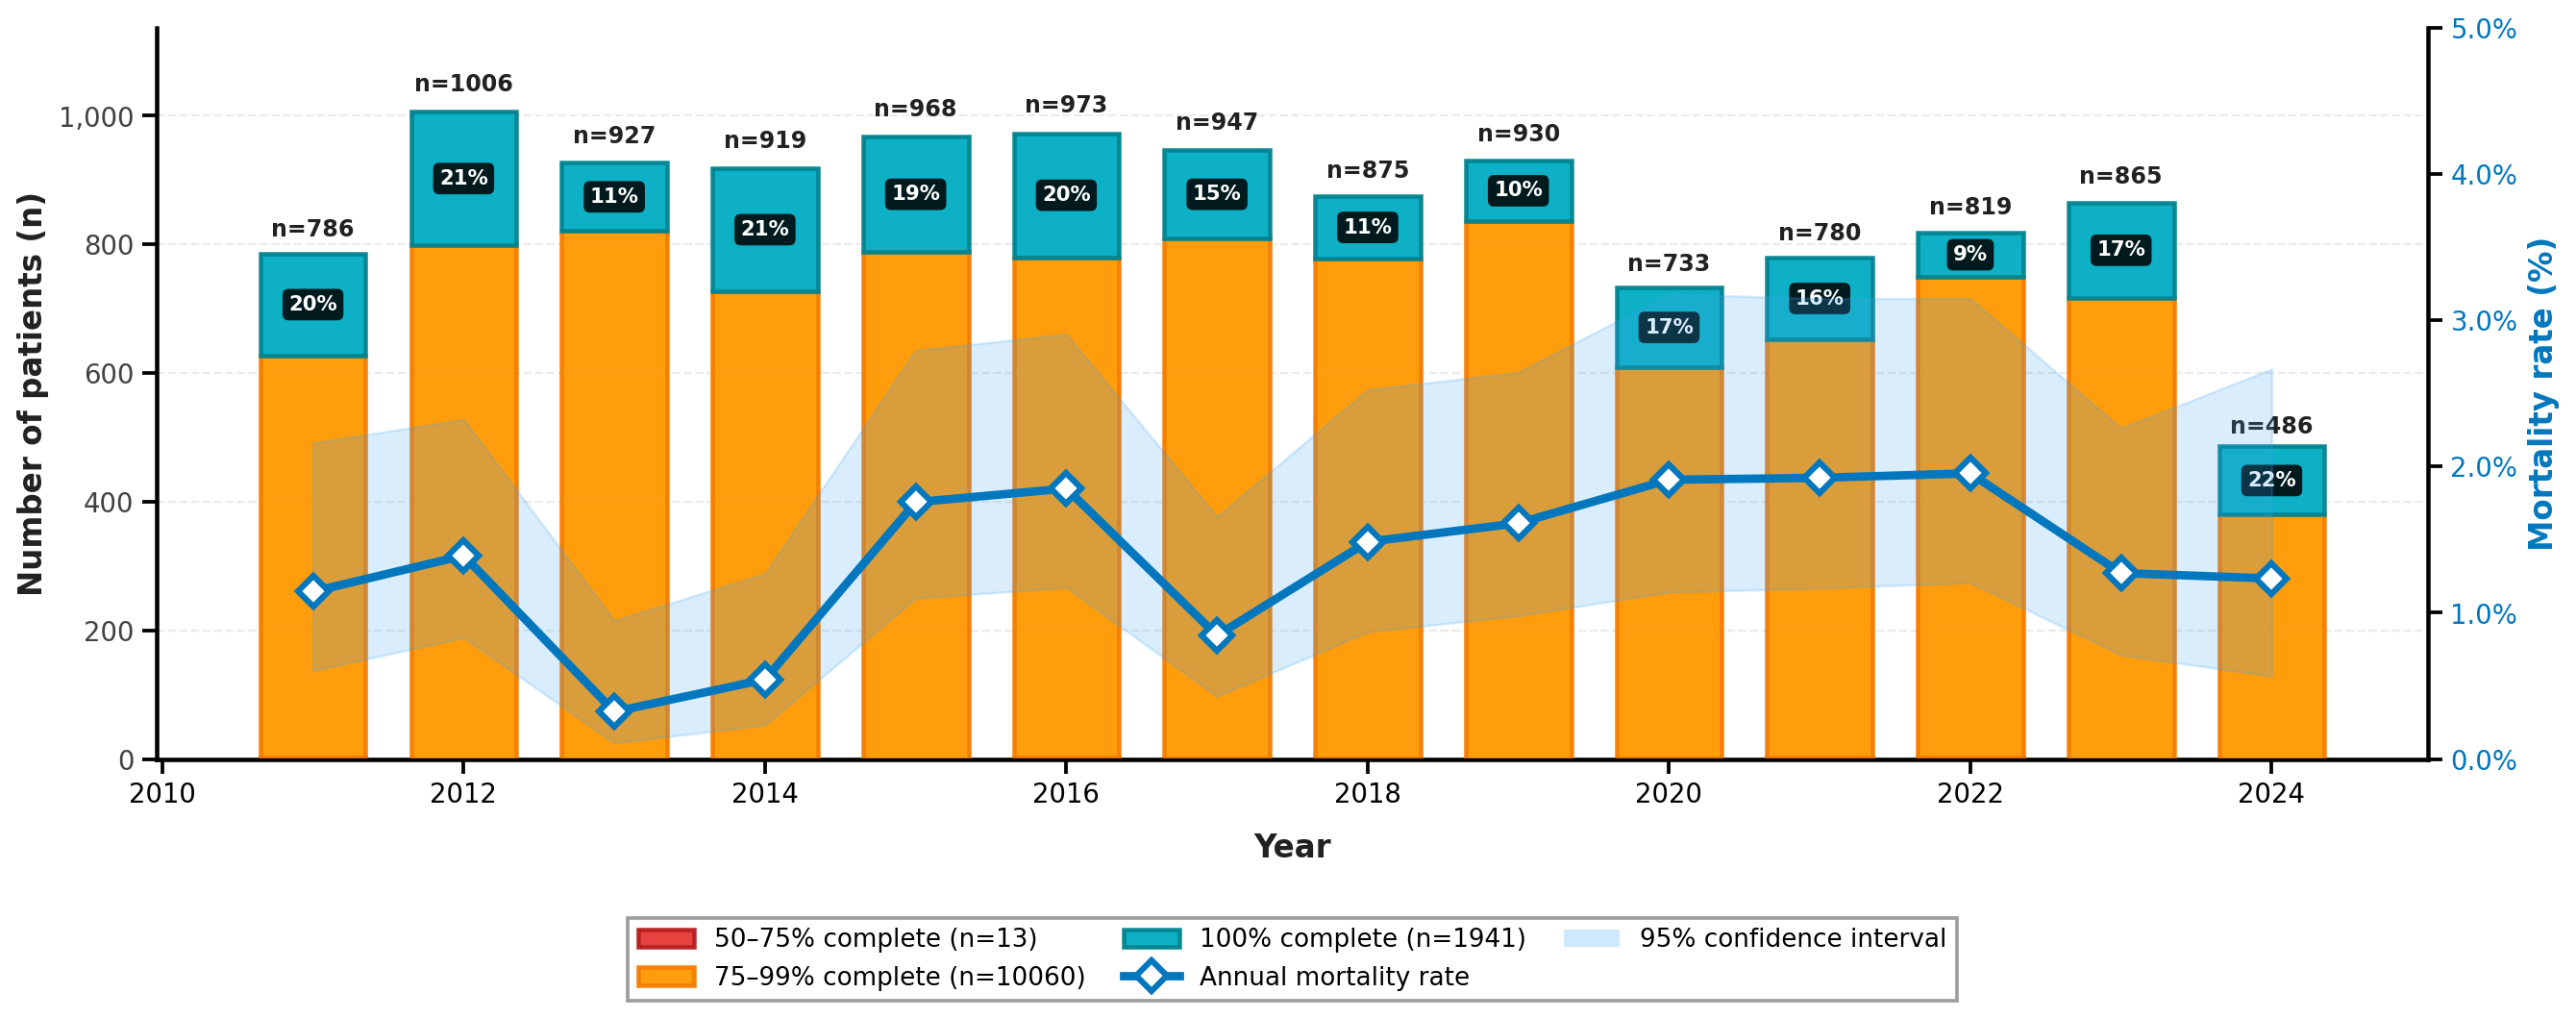

Annual Trends in Processed PICU-FE Dataset

 STATISTICAL SUMMARY

Sample Characteristics:
 • Study period: 2011–2024 (14 years)
 • Total patients: 12,014
 • Total records: 1,151,836
 • Records per patient: 95.9

Patient Volume by Year:
 • Mean: 858.1 ± 134.7 patients/year
 • Range: 486–1006 patients
 • Median: 897 patients

Data Completeness by Tier:
 • 100% Complete:  1941 patients (16.2%)
 • 75–99% Complete: 10060 patients (83.7%)
 • 50–74% Complete: 13 patients (0.1%)
 • 0–49% Complete:  0 patients (0.0%)

Annual 100% Complete Rate:
 • Mean: 16.3% ± 4.5%
 • Range: 8.5%–21.8%
 • Best year:  2024 (21.8%)
 • Worst year: 2022 (8.5%)

Mean Episode Completeness: 96.2% ± 4.7%

Data Density (Records/Patient/Year):
 • Mean: 95.9 ± 26.8
 • Range: 72.7–173.7

Mortality Rate:
 • Overall: 1.37% ± 0.52%
 • Range: 0.32%–1.95%
 • Total deaths: 164

Correlation Analysis:
 • 100% Completeness vs Mortality: r = -0.103 (p = 0.7269)

Temporal Trends:
 • Mortality trend:         +0.0546% per year (R² = 0

In [11]:
# ==========================================
# PUBLICATION-QUALITY CONFIGURATION
# ==========================================
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11, 'axes.labelsize': 13,
    'axes.titlesize': 14, 'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 10.5, 'figure.dpi': 150, 'axes.linewidth': 1.3,
    'grid.linewidth': 0.6, 'lines.linewidth': 3.0, 'xtick.major.width': 1.2,
    'ytick.major.width': 1.2, 'xtick.major.size': 5, 'ytick.major.size': 5,
})

# ==========================================
# 1. DATA PREPARATION
# ==========================================
df_work = df_final.copy(deep=True)
df_work.columns = df_work.columns.str.lower()
df_work.rename(columns={'id': 'id', 'hour': 'hour', 'outcome': 'outcome', 'sex': 'sex'}, inplace=True)

num_original_cols = df_work.shape[1]

# Year extraction
extracted_years = df_work['hour'].astype(str).str[:4].astype(float)
if 'year' in df_work.columns:
    df_work['year'] = df_work['year'].fillna(extracted_years).astype('Int64')
else:
    df_work['year'] = extracted_years.astype('Int64')

df_work.dropna(subset=['year'], inplace=True)

# Auto-detect death as the minority class of the outcome column
minority_class = df_work['outcome'].dropna().value_counts().idxmin()
df_work['is_dead'] = (df_work['outcome'] == minority_class).astype(int)

# ==========================================
# 2. VECTORIZED CALCULATIONS
# ==========================================
df_work['non_null_count'] = df_work.iloc[:, :num_original_cols].notna().sum(axis=1)

# Patient-level stats
patient_stats = df_work.groupby(['year', 'id']).agg(
    total_rows=('id', 'size'),
    total_non_nulls=('non_null_count', 'sum'),
    patient_died=('is_dead', 'max')
).reset_index()

patient_stats['total_cells'] = patient_stats['total_rows'] * num_original_cols
patient_stats['completeness_pct'] = (patient_stats['total_non_nulls'] / patient_stats['total_cells']) * 100

bins = [-1, 49.999, 74.999, 99.999, 101]
tier_labels = ['complete_0_49', 'complete_50_74', 'complete_75_99', 'complete_100']
patient_stats['tier'] = pd.cut(patient_stats['completeness_pct'], bins=bins, labels=tier_labels)

# Year-level stats
year_stats = patient_stats.groupby('year').agg(
    total_patients=('id', 'count'),
    deaths=('patient_died', 'sum'),
    density=('total_rows', 'mean')
)

tier_counts = patient_stats.groupby(['year', 'tier'], observed=False).size().unstack(fill_value=0)
tier_counts = tier_counts.reindex(columns=tier_labels, fill_value=0)

table = pd.concat([year_stats, tier_counts], axis=1)
table['rate'] = (table['deaths'] / table['total_patients']) * 100
table['pct_fully_complete'] = (table['complete_100'] / table['total_patients']) * 100

def vectorized_wilson_ci(successes, trials, z=1.96):
    p_hat = np.divide(successes, trials, out=np.zeros_like(successes, dtype=float), where=trials != 0)
    t_safe = np.where(trials == 0, 1, trials)

    denom = 1 + z**2 / t_safe
    center = (p_hat + z**2 / (2 * t_safe)) / denom
    margin = z * np.sqrt((p_hat * (1 - p_hat) / t_safe) + z**2 / (4 * t_safe**2)) / denom

    lower = np.clip(center - margin, 0, 1) * 100
    upper = np.clip(center + margin, 0, 1) * 100
    return np.where(trials == 0, 0, lower), np.where(trials == 0, 0, upper)

table['ci_lower'], table['ci_upper'] = vectorized_wilson_ci(table['deaths'].values, table['total_patients'].values)

# ==========================================
# 3. COMPUTE SUMMARY VARIABLES
# ==========================================
total_patients = int(table['total_patients'].sum())
total_records = len(df_work)
mean_density = total_records / total_patients if total_patients > 0 else 0
study_period = f"{int(table.index.min())}–{int(table.index.max())}"
overall_pct_complete = table['complete_100'].sum() / table['total_patients'].sum() * 100

# ==========================================
# 4. FIGURE CREATION
# ==========================================
fig, ax1 = plt.subplots(figsize=(15, 7.5))
fig.patch.set_facecolor('white')

colors = {
    'low': '#E53935', 'medium': '#FF9800', 'high': '#00ACC1',
    'mortality': '#0277BD', 'ci_fill': '#42A5F5'
}
bar_width = 0.7

ax1.bar(table.index, table['complete_50_74'], width=bar_width, color=colors['low'], alpha=0.95, edgecolor='#B71C1C', linewidth=1.8, zorder=3)
ax1.bar(table.index, table['complete_75_99'], width=bar_width, bottom=table['complete_50_74'], color=colors['medium'], alpha=0.95, edgecolor='#F57C00', linewidth=1.8, zorder=3)
ax1.bar(table.index, table['complete_100'], width=bar_width, bottom=table['complete_50_74'] + table['complete_75_99'], color=colors['high'], alpha=0.95, edgecolor='#00838F', linewidth=1.8, zorder=3)

for year in table.index:
    total = table.loc[year, 'total_patients']
    pct_complete = table.loc[year, 'pct_fully_complete']
    ax1.text(year, total * 1.025, f'n={int(total)}', ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#212121')

    if pct_complete > 0:
        y_pos = table.loc[year, 'complete_50_74'] + table.loc[year, 'complete_75_99'] + (table.loc[year, 'complete_100'] / 2)
        ax1.text(year, y_pos, f'{pct_complete:.0f}%', ha='center', va='center', fontsize=8.5, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.85, edgecolor='none'))

ax1.set_xlabel('Year', fontsize=13, fontweight='bold', color='#212121', labelpad=10)
ax1.set_ylabel('Number of patients (n)', fontsize=13, fontweight='bold', color='#212121')
ax1.tick_params(axis='y', labelcolor='#424242', width=1.5, length=6)
ax1.tick_params(axis='x', rotation=0, width=1.5, length=6)
ax1.set_ylim(0, table['total_patients'].max() * 1.13)
ax1.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.9, zorder=0, color='#BDBDBD')
ax1.set_axisbelow(True)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Secondary Axis
ax2 = ax1.twinx()
ax2.fill_between(table.index, table['ci_lower'], table['ci_upper'], color=colors['ci_fill'], alpha=0.2, zorder=4)
ax2.plot(table.index, table['rate'], color=colors['mortality'], marker='D', markersize=9,
         markerfacecolor='white', markeredgecolor=colors['mortality'], markeredgewidth=2.5, linewidth=3.5, zorder=5)

ax2.set_ylabel('Mortality rate (%)', fontsize=13, fontweight='bold', color=colors['mortality'])
ax2.tick_params(axis='y', labelcolor=colors['mortality'], width=1.5, length=6)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax2.set_ylim(0, max(table['ci_upper'].max() * 1.25, table['rate'].max() * 1.5, 5))

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
for spine in list(ax1.spines.values()) + [ax2.spines['right']]:
    spine.set_linewidth(1.8)

legend_elements = [
    Patch(facecolor=colors['low'], alpha=0.95, edgecolor='#B71C1C', linewidth=1.8),
    Patch(facecolor=colors['medium'], alpha=0.95, edgecolor='#F57C00', linewidth=1.8),
    Patch(facecolor=colors['high'], alpha=0.95, edgecolor='#00838F', linewidth=1.8),
    Line2D([0], [0], color=colors['mortality'], marker='D', linewidth=3.5, markersize=9, markerfacecolor='white', markeredgewidth=2.5),
    Patch(facecolor=colors['ci_fill'], alpha=0.25, edgecolor='none')
]
legend_labels = [
    f'50–75% complete (n={int(table["complete_50_74"].sum())})',
    f'75–99% complete (n={int(table["complete_75_99"].sum())})',
    f'100% complete (n={int(table["complete_100"].sum())})',
    f'Annual mortality rate',
    '95% confidence interval'
]

legend = ax1.legend(legend_elements, legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.20),
                    ncol=3, frameon=True, fancybox=False, framealpha=1.0, edgecolor='#9E9E9E',
                    fontsize=10.5, handlelength=2.2, columnspacing=1.5, handletextpad=0.8)
legend.get_frame().set_linewidth(1.5)

plt.tight_layout(rect=[0, 0.16, 1, 1.0])
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=180, bbox_inches='tight', facecolor='white')
plt.close(fig)
buf.seek(0)
display(Image(data=buf.read()))

print('Annual Trends in Processed PICU-FE Dataset')

# ==========================================
# 5. STATISTICAL SUMMARY
# ==========================================
print(f"\n{'='*70}\n STATISTICAL SUMMARY\n{'='*70}")
print(f"\nSample Characteristics:\n • Study period: {study_period} ({len(table)} years)\n • Total patients: {total_patients:,}\n • Total records: {total_records:,}\n • Records per patient: {total_records/total_patients:.1f}")
print(f"\nPatient Volume by Year:\n • Mean: {table['total_patients'].mean():.1f} ± {table['total_patients'].std():.1f} patients/year\n • Range: {table['total_patients'].min():.0f}–{table['total_patients'].max():.0f} patients\n • Median: {table['total_patients'].median():.0f} patients")
print(f"\nData Completeness by Tier:\n • 100% Complete:  {table['complete_100'].sum():.0f} patients ({overall_pct_complete:.1f}%)\n • 75–99% Complete: {table['complete_75_99'].sum():.0f} patients ({table['complete_75_99'].sum()/total_patients*100:.1f}%)\n • 50–74% Complete: {table['complete_50_74'].sum():.0f} patients ({table['complete_50_74'].sum()/total_patients*100:.1f}%)\n • 0–49% Complete:  {table['complete_0_49'].sum():.0f} patients ({table['complete_0_49'].sum()/total_patients*100:.1f}%)")
print(f"\nAnnual 100% Complete Rate:\n • Mean: {table['pct_fully_complete'].mean():.1f}% ± {table['pct_fully_complete'].std():.1f}%\n • Range: {table['pct_fully_complete'].min():.1f}%–{table['pct_fully_complete'].max():.1f}%\n • Best year:  {table['pct_fully_complete'].idxmax()} ({table['pct_fully_complete'].max():.1f}%)\n • Worst year: {table['pct_fully_complete'].idxmin()} ({table['pct_fully_complete'].min():.1f}%)")
print(f"\nMean Episode Completeness: {patient_stats['completeness_pct'].mean():.1f}% ± {patient_stats['completeness_pct'].std():.1f}%")
print(f"\nData Density (Records/Patient/Year):\n • Mean: {mean_density:.1f} ± {table['density'].std():.1f}\n • Range: {table['density'].min():.1f}–{table['density'].max():.1f}")
print(f"\nMortality Rate:\n • Overall: {table['rate'].mean():.2f}% ± {table['rate'].std():.2f}%\n • Range: {table['rate'].min():.2f}%–{table['rate'].max():.2f}%\n • Total deaths: {table['deaths'].sum():.0f}")

if table['rate'].std() == 0 or table['pct_fully_complete'].std() == 0:
    print("\nCorrelation Analysis:\n • 100% Completeness vs Mortality: Not calculable (Zero variance)")
else:
    corr_complete_mort, p_complete_mort = stats.pearsonr(table['pct_fully_complete'], table['rate'])
    print(f"\nCorrelation Analysis:\n • 100% Completeness vs Mortality: r = {corr_complete_mort:.3f} (p = {p_complete_mort:.4f})")

slope_mort, _, r_value_mort, p_value_mort, _ = stats.linregress(table.index, table['rate'])
slope_comp, _, r_value_comp, p_value_comp, _ = stats.linregress(table.index, table['pct_fully_complete'])

print(f"\nTemporal Trends:\n • Mortality trend:         {slope_mort:+.4f}% per year (R² = {r_value_mort**2:.3f}, p = {p_value_mort:.4f})\n • 100% Completeness trend: {slope_comp:+.3f}% per year (R² = {r_value_comp**2:.3f}, p = {p_value_comp:.4f})")
print(f"\n{'='*70}\n")

## 4.3 Quality Metrics

this section evaluate the reliability and integrity of the clinical data through several technical validation lenses:

*   **Intra-patient volatility**: Using the ECDF of the Coefficient of Variation (CV) to understand sensor and biological stability.
*   **Feature Distribution**: Analyzing robust-scaled variables to compare populations.
*   **Prognostic Utility**: Measuring the baseline discriminative signal strength (AUC-ROC) for individual vitals.
*   **Signal Stability**: Assessing temporal predictability via Lag-1 Autocorrelation.

A. Data Quality: Sensor & Biological Volatility (ECDF)
B. Feature Distribution (Robust Scaled)
C. Baseline Prognostic Utility (AUC-ROC)
D. Signal Stability (Lag-1 Autocorrelation)


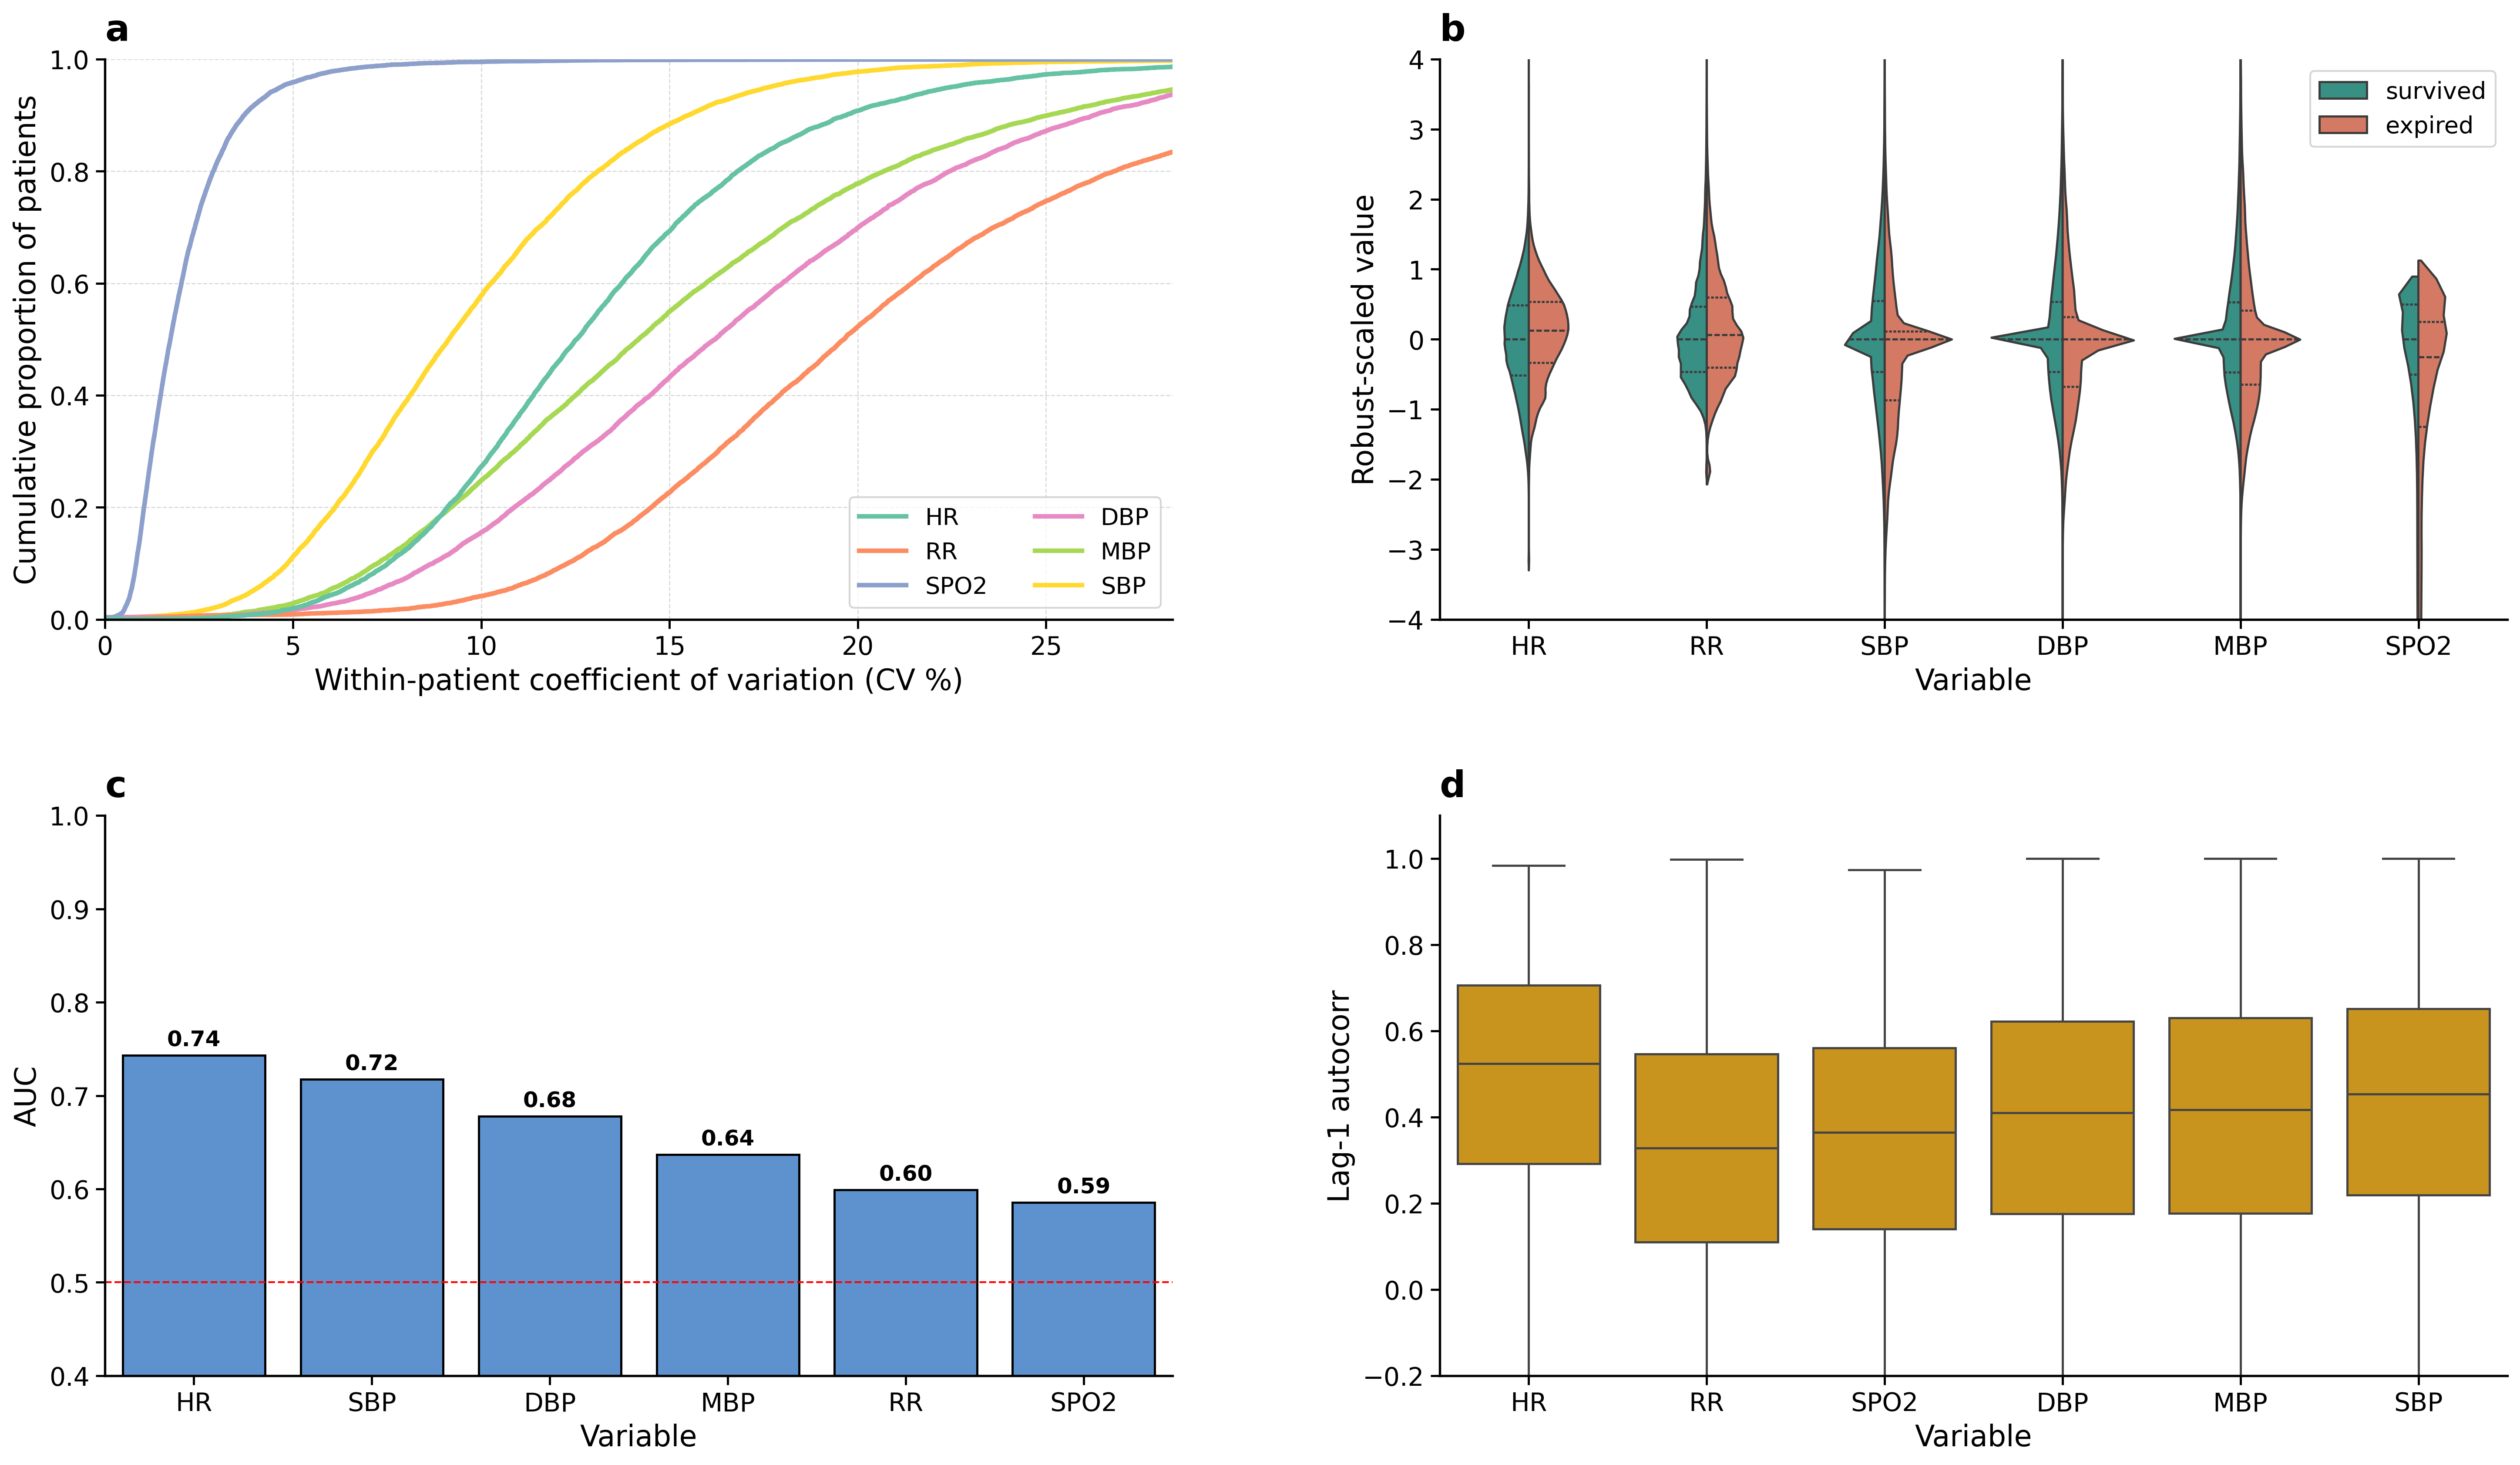

'output/quality_metrics_figure.png'

In [10]:
warnings.filterwarnings("ignore")

# =====================================================================
# QUALITY STYLE AND CONFIGURATION
# =====================================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.dpi": 150,
    "axes.linewidth": 1.3,
    "grid.linewidth": 0.6,
})

VITALS = ("HR", "RR", "SPO2", "TEMP", "DBP", "MBP", "SBP")


def _lag1_autocorr_fast(df, id_col, value_col, min_pairs=6):
    x = pd.to_numeric(df[value_col], errors="coerce")
    x_lag = df.groupby(id_col, sort=False)[value_col].shift(1)

    tmp = pd.DataFrame({
        id_col: df[id_col].to_numpy(),
        "x": x.to_numpy(),
        "x_lag": x_lag.to_numpy(),
    }).dropna(subset=["x", "x_lag"])

    if tmp.empty:
        return pd.Series(dtype=float)

    tmp["x2"] = tmp["x"] * tmp["x"]
    tmp["y2"] = tmp["x_lag"] * tmp["x_lag"]
    tmp["xy"] = tmp["x"] * tmp["x_lag"]

    g = tmp.groupby(id_col, sort=False)
    sums = g[["x", "x_lag", "x2", "y2", "xy"]].sum()
    n = g.size().astype(float)

    sx = sums["x"].to_numpy()
    sy = sums["x_lag"].to_numpy()
    sxx = sums["x2"].to_numpy()
    syy = sums["y2"].to_numpy()
    sxy = sums["xy"].to_numpy()
    n_arr = n.to_numpy()

    num = sxy - (sx * sy) / n_arr
    den_x = sxx - (sx * sx) / n_arr
    den_y = syy - (sy * sy) / n_arr
    den = np.sqrt(den_x * den_y)

    with np.errstate(divide="ignore", invalid="ignore"):
        corr = num / den

    corr = pd.Series(corr, index=sums.index)
    corr = corr.replace([np.inf, -np.inf], np.nan)
    corr[n < min_pairs] = np.nan
    return corr


# =====================================================================
# CORE QUALITY METRICS PIPELINE
# =====================================================================
def quality_metrics(df_input, out_png="technical_validation_figure.png"):
    # -----------------------------------------------------------------
    # 1. DATA PREPARATION & AUTO-DETECTION
    # -----------------------------------------------------------------
    df = df_input.copy()
    df.columns = df.columns.str.upper().str.strip()

    core_vitals = [c for c in VITALS if c in df.columns]

    for col in core_vitals:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "OUTCOME" not in df.columns:
        raise ValueError("The dataframe must contain an 'OUTCOME' column.")

    df["OUTCOME"] = (
        df["OUTCOME"]
        .where(df["OUTCOME"].notna(), "MISSING")
        .astype(str)
        .str.lower()
        .str.strip()
    )

    outcome_counts = df["OUTCOME"].value_counts(dropna=False)
    unique_outcomes = outcome_counts.index.to_list()

    if len(unique_outcomes) < 2:
        raise ValueError(f"Expected at least two outcome categories. Found: {unique_outcomes}")

    minority_class = outcome_counts.idxmin()
    majority_class = outcome_counts.idxmax()
    df["TARGET_NUM"] = (df["OUTCOME"] == minority_class).astype(np.int8)

    id_grouped = df.groupby("ID", sort=False) if "ID" in df.columns else None

    os.makedirs("output", exist_ok=True)
    out_path = os.path.join("output", out_png)

    # -----------------------------------------------------------------
    # PRINTED PANEL TITLES FOR THE READER
    # -----------------------------------------------------------------
    print("A. Data Quality: Sensor & Biological Volatility (ECDF)")
    print("B. Feature Distribution (Robust Scaled)")
    print("C. Baseline Prognostic Utility (AUC-ROC)")
    print("D. Signal Stability (Lag-1 Autocorrelation)")

    # -----------------------------------------------------------------
    # FIGURE LAYOUT
    # -----------------------------------------------------------------
    fig = plt.figure(figsize=(20, 12), dpi=300)
    gs = fig.add_gridspec(
        2, 2, hspace=0.35, wspace=0.25,
        left=0.06, right=0.98, top=0.92, bottom=0.08
    )

    # -----------------------------------------------------------------
    # PANEL A: DATA QUALITY - WITHIN-PATIENT VOLATILITY (ECDF)
    # -----------------------------------------------------------------
    ax0 = fig.add_subplot(gs[0, 0])

    if id_grouped is not None and core_vitals:
        stats = id_grouped[core_vitals].agg(["mean", "std"])
        df_mean = stats.xs("mean", axis=1, level=1)
        df_std = stats.xs("std", axis=1, level=1)

        df_cv = (df_std / df_mean.replace(0, np.nan)) * 100
        df_cv.replace([np.inf, -np.inf], np.nan, inplace=True)

        df_cv_melt = (
            df_cv.reset_index()
            .melt(id_vars="ID", value_vars=core_vitals, var_name="Variable", value_name="CV (%)")
            .dropna()
        )

        if not df_cv_melt.empty:
            sns.ecdfplot(
                data=df_cv_melt,
                x="CV (%)",
                hue="Variable",
                ax=ax0,
                linewidth=2.5,
                palette="Set2"
            )

            x_limit = df_cv_melt["CV (%)"].quantile(0.95)
            ax0.set_xlim(0, x_limit if pd.notna(x_limit) and x_limit > 0 else 100)
            ax0.set_xlabel("Within-patient coefficient of variation (CV %)")
            ax0.set_ylabel("Cumulative proportion of patients")
            ax0.grid(axis="both", linestyle="--", alpha=0.5)
            sns.move_legend(ax0, "lower right", frameon=True, title=None, ncol=2)
            leg = ax0.get_legend()
            if leg is not None:
                plt.setp(leg.get_texts(), fontsize=11)
        else:
            ax0.text(0.5, 0.5, "Volatility not available", ha="center", va="center")
            ax0.set_axis_off()
    else:
        ax0.text(0.5, 0.5, "ID column required for patient-level quality metrics", ha="center", va="center")
        ax0.set_axis_off()

    ax0.text(
        0.0, 1.02, "a",
        transform=ax0.transAxes,
        fontweight="black",
        fontsize=20,
        va="bottom",
        ha="left"
    )
    sns.despine(ax=ax0)

    # -----------------------------------------------------------------
    # PANEL B: FEATURE DISTRIBUTION (ROBUST SCALED)
    # -----------------------------------------------------------------
    ax1 = fig.add_subplot(gs[0, 1])

    if core_vitals:
        plot_vars_b = core_vitals.copy()

        if "SPO2" in plot_vars_b and "SBP" in plot_vars_b:
            idx_spo2, idx_sbp = plot_vars_b.index("SPO2"), plot_vars_b.index("SBP")
            plot_vars_b[idx_spo2], plot_vars_b[idx_sbp] = plot_vars_b[idx_sbp], plot_vars_b[idx_spo2]

        valid_cols = [c for c in plot_vars_b if c in df.columns]
        data_for_scaling = df[valid_cols].copy().apply(pd.to_numeric, errors="coerce")
        data_for_scaling.fillna(data_for_scaling.median(numeric_only=True), inplace=True)

        scaler = RobustScaler()
        df_scaled_vals = scaler.fit_transform(data_for_scaling.to_numpy(dtype=float, copy=False))
        df_scaled = pd.DataFrame(df_scaled_vals, columns=valid_cols, index=df.index)
        df_scaled["OUTCOME"] = df["OUTCOME"].to_numpy()

        df_melt = df_scaled.melt(id_vars="OUTCOME", value_vars=valid_cols).dropna()

        if len(unique_outcomes) == 2:
            panel_b_palette = {
                majority_class: "#2A9D8F",
                minority_class: "#E76F51",
            }
        else:
            panel_b_palette = dict(zip(
                unique_outcomes,
                sns.color_palette("crest", n_colors=len(unique_outcomes))
            ))

        violin_kwargs = dict(
            data=df_melt,
            x="variable",
            y="value",
            hue="OUTCOME",
            hue_order=unique_outcomes,
            inner="quartile",
            palette=panel_b_palette,
            ax=ax1,
            linewidth=1.2
        )

        if len(unique_outcomes) == 2:
            sns.violinplot(split=True, **violin_kwargs)
        else:
            sns.violinplot(dodge=True, **violin_kwargs)

        ax1.legend(loc="upper right", frameon=True, title=None)
        ax1.set_ylim(-4, 4)
        ax1.set_xlabel("Variable")
        ax1.set_ylabel("Robust-scaled value")
    else:
        ax1.text(0.5, 0.5, "No vital signs available", ha="center", va="center")
        ax1.set_axis_off()

    ax1.text(
        0.0, 1.02, "b",
        transform=ax1.transAxes,
        fontweight="black",
        fontsize=20,
        va="bottom",
        ha="left"
    )
    sns.despine(ax=ax1)

    # -----------------------------------------------------------------
    # PANEL C: BASELINE PROGNOSTIC UTILITY (AUC-ROC)
    # -----------------------------------------------------------------
    ax2 = fig.add_subplot(gs[1, 0])

    if id_grouped is not None and core_vitals:
        agg_dict = {"TARGET_NUM": "first"}
        agg_dict.update({v: "median" for v in core_vitals})
        df_patient = id_grouped.agg(agg_dict).dropna()

        auc_data = []
        if not df_patient.empty and df_patient["TARGET_NUM"].nunique() >= 2:
            y_true = df_patient["TARGET_NUM"].to_numpy()

            for col in core_vitals:
                y_score = df_patient[col].to_numpy()
                y_score = y_score[~np.isnan(y_score)]

                if np.unique(y_score).size > 1:
                    score = roc_auc_score(y_true, df_patient[col].to_numpy())
                    score = score if score >= 0.5 else 1 - score
                    auc_data.append({"Variable": col, "AUC": score})

        df_auc = pd.DataFrame(auc_data).sort_values("AUC", ascending=False) if auc_data else pd.DataFrame()

        if not df_auc.empty:
            sns.barplot(
                data=df_auc,
                x="Variable",
                y="AUC",
                color="#4A90E2",
                ax=ax2,
                edgecolor="black",
                linewidth=1.2
            )
            ax2.axhline(0.5, color="red", linestyle="--", linewidth=1)
            ax2.set_ylim(0.4, 1.0)

            for i, v in enumerate(df_auc["AUC"]):
                ax2.text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold", fontsize=10)

            ax2.set_xlabel("Variable")
            ax2.set_ylabel("AUC")
        else:
            ax2.text(0.5, 0.5, "AUC not available", ha="center", va="center")
            ax2.set_axis_off()
    else:
        ax2.text(0.5, 0.5, "Patient-level aggregation not available", ha="center", va="center")
        ax2.set_axis_off()

    ax2.text(
        0.0, 1.02, "c",
        transform=ax2.transAxes,
        fontweight="black",
        fontsize=20,
        va="bottom",
        ha="left"
    )
    sns.despine(ax=ax2)

    # -----------------------------------------------------------------
    # PANEL D: SIGNAL STABILITY (LAG-1 AUTOCORRELATION)
    # -----------------------------------------------------------------
    ax3 = fig.add_subplot(gs[1, 1])

    stability_frames = []
    if id_grouped is not None and core_vitals:
        for col in core_vitals:
            ac = _lag1_autocorr_fast(df, "ID", col).dropna()
            if not ac.empty:
                stability_frames.append(pd.DataFrame({
                    "Variable": col,
                    "AutoCorr": ac.to_numpy()
                }))

    if stability_frames:
        df_st = pd.concat(stability_frames, ignore_index=True)
        sns.boxplot(
            data=df_st,
            x="Variable",
            y="AutoCorr",
            color="#E69F00",
            ax=ax3,
            fliersize=1,
            linewidth=1.2
        )
        ax3.set_ylim(-0.2, 1.1)
        ax3.set_xlabel("Variable")
        ax3.set_ylabel("Lag-1 autocorr")
    else:
        ax3.text(0.5, 0.5, "Stability not available", ha="center", va="center")
        ax3.set_axis_off()

    ax3.text(
        0.0, 1.02, "d",
        transform=ax3.transAxes,
        fontweight="black",
        fontsize=20,
        va="bottom",
        ha="left"
    )
    sns.despine(ax=ax3)

    # -----------------------------------------------------------------
    # FILE EXPORT AND RENDER
    # -----------------------------------------------------------------
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return out_path

warnings.filterwarnings("ignore")

# =====================================================================
# QUALITY STYLE AND CONFIGURATION
# =====================================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.dpi": 150,
    "axes.linewidth": 1.3,
    "grid.linewidth": 0.6,
})

VITALS = ("HR", "RR", "SPO2", "TEMP", "DBP", "MBP", "SBP")


def _lag1_autocorr_fast(df, id_col, value_col, min_pairs=6):
    x = pd.to_numeric(df[value_col], errors="coerce")
    x_lag = df.groupby(id_col, sort=False)[value_col].shift(1)

    tmp = pd.DataFrame({
        id_col: df[id_col].to_numpy(),
        "x": x.to_numpy(),
        "x_lag": x_lag.to_numpy(),
    }).dropna(subset=["x", "x_lag"])

    if tmp.empty:
        return pd.Series(dtype=float)

    tmp["x2"] = tmp["x"] * tmp["x"]
    tmp["y2"] = tmp["x_lag"] * tmp["x_lag"]
    tmp["xy"] = tmp["x"] * tmp["x_lag"]

    g = tmp.groupby(id_col, sort=False)
    sums = g[["x", "x_lag", "x2", "y2", "xy"]].sum()
    n = g.size().astype(float)

    sx = sums["x"].to_numpy()
    sy = sums["x_lag"].to_numpy()
    sxx = sums["x2"].to_numpy()
    syy = sums["y2"].to_numpy()
    sxy = sums["xy"].to_numpy()
    n_arr = n.to_numpy()

    num = sxy - (sx * sy) / n_arr
    den_x = sxx - (sx * sx) / n_arr
    den_y = syy - (sy * sy) / n_arr
    den = np.sqrt(den_x * den_y)

    with np.errstate(divide="ignore", invalid="ignore"):
        corr = num / den

    corr = pd.Series(corr, index=sums.index)
    corr = corr.replace([np.inf, -np.inf], np.nan)
    corr[n < min_pairs] = np.nan
    return corr


# =====================================================================
# CORE QUALITY METRICS PIPELINE
# =====================================================================
def quality_metrics(df_input, out_png="technical_validation_figure.png"):
    # -----------------------------------------------------------------
    # 1. DATA PREPARATION & AUTO-DETECTION
    # -----------------------------------------------------------------
    df = df_input.copy()
    df.columns = df.columns.str.upper().str.strip()

    core_vitals = [c for c in VITALS if c in df.columns]

    for col in core_vitals:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "OUTCOME" not in df.columns:
        raise ValueError("The dataframe must contain an 'OUTCOME' column.")

    df["OUTCOME"] = (
        df["OUTCOME"]
        .where(df["OUTCOME"].notna(), "MISSING")
        .astype(str)
        .str.lower()
        .str.strip()
    )

    outcome_counts = df["OUTCOME"].value_counts(dropna=False)
    unique_outcomes = outcome_counts.index.to_list()

    if len(unique_outcomes) < 2:
        raise ValueError(f"Expected at least two outcome categories. Found: {unique_outcomes}")

    minority_class = outcome_counts.idxmin()
    majority_class = outcome_counts.idxmax()
    df["TARGET_NUM"] = (df["OUTCOME"] == minority_class).astype(np.int8)

    id_grouped = df.groupby("ID", sort=False) if "ID" in df.columns else None

    os.makedirs("output", exist_ok=True)
    out_path = os.path.join("output", out_png)

    # -----------------------------------------------------------------
    # PRINTED PANEL TITLES FOR THE READER
    # -----------------------------------------------------------------
    print("A. Data Quality: Sensor & Biological Volatility (ECDF)")
    print("B. Feature Distribution (Robust Scaled)")
    print("C. Baseline Prognostic Utility (AUC-ROC)")
    print("D. Signal Stability (Lag-1 Autocorrelation)")

    # -----------------------------------------------------------------
    # FIGURE LAYOUT
    # -----------------------------------------------------------------
    fig = plt.figure(figsize=(20, 12), dpi=300)
    gs = fig.add_gridspec(
        2, 2, hspace=0.35, wspace=0.25,
        left=0.06, right=0.98, top=0.92, bottom=0.08
    )

    # -----------------------------------------------------------------
    # PANEL A: DATA QUALITY - WITHIN-PATIENT VOLATILITY (ECDF)
    # -----------------------------------------------------------------
    ax0 = fig.add_subplot(gs[0, 0])

    if id_grouped is not None and core_vitals:
        stats = id_grouped[core_vitals].agg(["mean", "std"])
        df_mean = stats.xs("mean", axis=1, level=1)
        df_std = stats.xs("std", axis=1, level=1)

        df_cv = (df_std / df_mean.replace(0, np.nan)) * 100
        df_cv.replace([np.inf, -np.inf], np.nan, inplace=True)

        df_cv_melt = (
            df_cv.reset_index()
            .melt(id_vars="ID", value_vars=core_vitals, var_name="Variable", value_name="CV (%)")
            .dropna()
        )

        if not df_cv_melt.empty:
            sns.ecdfplot(
                data=df_cv_melt,
                x="CV (%)",
                hue="Variable",
                ax=ax0,
                linewidth=2.5,
                palette="Set2"
            )

            x_limit = df_cv_melt["CV (%)"].quantile(0.95)
            ax0.set_xlim(0, x_limit if pd.notna(x_limit) and x_limit > 0 else 100)
            ax0.set_xlabel("Within-patient coefficient of variation (CV %)")
            ax0.set_ylabel("Cumulative proportion of patients")
            ax0.grid(axis="both", linestyle="--", alpha=0.5)
            sns.move_legend(ax0, "lower right", frameon=True, title=None, ncol=2)
            leg = ax0.get_legend()
            if leg is not None:
                plt.setp(leg.get_texts(), fontsize=13)
        else:
            ax0.text(0.5, 0.5, "Volatility not available", ha="center", va="center")
            ax0.set_axis_off()
    else:
        ax0.text(0.5, 0.5, "ID column required for patient-level quality metrics", ha="center", va="center")
        ax0.set_axis_off()

    ax0.text(
        0.0, 1.02, "a",
        transform=ax0.transAxes,
        fontweight="black",
        fontsize=20,
        va="bottom",
        ha="left"
    )
    sns.despine(ax=ax0)

    # -----------------------------------------------------------------
    # PANEL B: FEATURE DISTRIBUTION (ROBUST SCALED)
    # -----------------------------------------------------------------
    ax1 = fig.add_subplot(gs[0, 1])

    if core_vitals:
        plot_vars_b = core_vitals.copy()

        if "SPO2" in plot_vars_b and "SBP" in plot_vars_b:
            idx_spo2, idx_sbp = plot_vars_b.index("SPO2"), plot_vars_b.index("SBP")
            plot_vars_b[idx_spo2], plot_vars_b[idx_sbp] = plot_vars_b[idx_sbp], plot_vars_b[idx_spo2]

        valid_cols = [c for c in plot_vars_b if c in df.columns]
        data_for_scaling = df[valid_cols].copy().apply(pd.to_numeric, errors="coerce")
        data_for_scaling.fillna(data_for_scaling.median(numeric_only=True), inplace=True)

        scaler = RobustScaler()
        df_scaled_vals = scaler.fit_transform(data_for_scaling.to_numpy(dtype=float, copy=False))
        df_scaled = pd.DataFrame(df_scaled_vals, columns=valid_cols, index=df.index)
        df_scaled["OUTCOME"] = df["OUTCOME"].to_numpy()

        df_melt = df_scaled.melt(id_vars="OUTCOME", value_vars=valid_cols).dropna()

        if len(unique_outcomes) == 2:
            panel_b_palette = {
                majority_class: "#2A9D8F",
                minority_class: "#E76F51",
            }
        else:
            panel_b_palette = dict(zip(
                unique_outcomes,
                sns.color_palette("crest", n_colors=len(unique_outcomes))
            ))

        violin_kwargs = dict(
            data=df_melt,
            x="variable",
            y="value",
            hue="OUTCOME",
            hue_order=unique_outcomes,
            inner="quartile",
            palette=panel_b_palette,
            ax=ax1,
            linewidth=1.2
        )

        if len(unique_outcomes) == 2:
            sns.violinplot(split=True, **violin_kwargs)
        else:
            sns.violinplot(dodge=True, **violin_kwargs)

        ax1.legend(loc="upper right", frameon=True, title=None, fontsize=13)
        ax1.set_ylim(-4, 4)
        ax1.set_xlabel("Variable")
        ax1.set_ylabel("Robust-scaled value")
    else:
        ax1.text(0.5, 0.5, "No vital signs available", ha="center", va="center")
        ax1.set_axis_off()

    ax1.text(
        0.0, 1.02, "b",
        transform=ax1.transAxes,
        fontweight="black",
        fontsize=20,
        va="bottom",
        ha="left"
    )
    sns.despine(ax=ax1)

    # -----------------------------------------------------------------
    # PANEL C: BASELINE PROGNOSTIC UTILITY (AUC-ROC)
    # -----------------------------------------------------------------
    ax2 = fig.add_subplot(gs[1, 0])

    if id_grouped is not None and core_vitals:
        agg_dict = {"TARGET_NUM": "first"}
        agg_dict.update({v: "median" for v in core_vitals})
        df_patient = id_grouped.agg(agg_dict).dropna()

        auc_data = []
        if not df_patient.empty and df_patient["TARGET_NUM"].nunique() >= 2:
            y_true = df_patient["TARGET_NUM"].to_numpy()

            for col in core_vitals:
                y_score = df_patient[col].to_numpy()
                y_score = y_score[~np.isnan(y_score)]

                if np.unique(y_score).size > 1:
                    score = roc_auc_score(y_true, df_patient[col].to_numpy())
                    score = score if score >= 0.5 else 1 - score
                    auc_data.append({"Variable": col, "AUC": score})

        df_auc = pd.DataFrame(auc_data).sort_values("AUC", ascending=False) if auc_data else pd.DataFrame()

        if not df_auc.empty:
            sns.barplot(
                data=df_auc,
                x="Variable",
                y="AUC",
                color="#4A90E2",
                ax=ax2,
                edgecolor="black",
                linewidth=1.2
            )
            ax2.axhline(0.5, color="red", linestyle="--", linewidth=1)
            ax2.set_ylim(0.4, 1.0)

            for i, v in enumerate(df_auc["AUC"]):
                ax2.text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold", fontsize=12)

            ax2.set_xlabel("Variable")
            ax2.set_ylabel("AUC")
        else:
            ax2.text(0.5, 0.5, "AUC not available", ha="center", va="center")
            ax2.set_axis_off()
    else:
        ax2.text(0.5, 0.5, "Patient-level aggregation not available", ha="center", va="center")
        ax2.set_axis_off()

    ax2.text(
        0.0, 1.02, "c",
        transform=ax2.transAxes,
        fontweight="black",
        fontsize=20,
        va="bottom",
        ha="left"
    )
    sns.despine(ax=ax2)

    # -----------------------------------------------------------------
    # PANEL D: SIGNAL STABILITY (LAG-1 AUTOCORRELATION)
    # -----------------------------------------------------------------
    ax3 = fig.add_subplot(gs[1, 1])

    stability_frames = []
    if id_grouped is not None and core_vitals:
        for col in core_vitals:
            ac = _lag1_autocorr_fast(df, "ID", col).dropna()
            if not ac.empty:
                stability_frames.append(pd.DataFrame({
                    "Variable": col,
                    "AutoCorr": ac.to_numpy()
                }))

    if stability_frames:
        df_st = pd.concat(stability_frames, ignore_index=True)
        sns.boxplot(
            data=df_st,
            x="Variable",
            y="AutoCorr",
            color="#E69F00",
            ax=ax3,
            fliersize=1,
            linewidth=1.2
        )
        ax3.set_ylim(-0.2, 1.1)
        ax3.set_xlabel("Variable")
        ax3.set_ylabel("Lag-1 autocorr")
    else:
        ax3.text(0.5, 0.5, "Stability not available", ha="center", va="center")
        ax3.set_axis_off()

    ax3.text(
        0.0, 1.02, "d",
        transform=ax3.transAxes,
        fontweight="black",
        fontsize=20,
        va="bottom",
        ha="left"
    )
    sns.despine(ax=ax3)

    # -----------------------------------------------------------------
    # FILE EXPORT AND RENDER
    # -----------------------------------------------------------------
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return out_path


# =====================================================================
# EXECUTION
# =====================================================================
quality_metrics(df_final, out_png="quality_metrics_figure.png")

# 6. Performance Validation

To evaluate the prognostic utility of the processed dataset, a standardized machine learning framework is implemented, characterized by:

*   **Feature Engineering**: Extraction of first-order temporal signatures (Minimum, Maximum, Trend, Range, and Standard Deviation) from dynamic physiological variables.
*   **Class Imbalance Management**: Implementation of cost-sensitive learning (balanced class weights) and threshold optimization to account for low target prevalence.
*   **Threshold Optimization**: Selection of optimal classification thresholds based on the maximum **F1-score** to balance precision and recall in a clinical context.
*   **Robust Evaluation**: Implementation of nested cross-validation to ensure unbiased performance estimation, prioritizing **Area Under the Precision-Recall Curve (AUC-PR)** and MCC as primary metrics for imbalanced data.
*   **Probability Calibration**: Application of Sigmoid (Platt) calibration to align model output probabilities with observed clinical risk.
*   **Statistical Reliability**: Uncertainty quantification through 95% Confidence Intervals (CI) calculated via 2,000 bootstrap iterations.

In [8]:
# =============================================================================
# 1. TEMPORAL FEATURE ENGINEERING
# =============================================================================
def extract_temporal_features(df_final, vitals, statics, target="OUTCOME"):
    df_final = df_final.copy()

    # Standardise column labels
    df_final.columns = df_final.columns.str.strip().str.upper()

    # Ensure explicit ID column
    if 'ID' not in df_final.columns and (df_final.index.name is not None and df_final.index.name.strip().upper() == 'ID'):
        df_final.index.name = 'ID'
        df_final = df_final.reset_index()

    # Validate required fields
    if 'ID' not in df_final.columns:
        raise KeyError(f"Required column 'ID' not found. Available columns: {list(df_final.columns)}")
    if target not in df_final.columns:
        raise KeyError(f"Required target '{target}' not found. Available columns: {list(df_final.columns)}")

    # Standardise missing string representations
    obj_cols = df_final.select_dtypes(include=["object", "string"]).columns
    if not obj_cols.empty:
        df_final[obj_cols] = df_final[obj_cols].replace(["nan", "NaN", "None", ""], np.nan)

    # Coerce temporal and static numericals
    cols_to_numeric = [c for c in vitals + ["AGE"] if c in df_final.columns]
    if cols_to_numeric:
        df_final[cols_to_numeric] = df_final[cols_to_numeric].apply(pd.to_numeric, errors="coerce")

    grouped = df_final.groupby("ID", sort=False)

    # Extract static features and target
    keep_cols = [c for c in statics if c in df_final.columns] + [target]
    df_features = grouped[keep_cols].first().copy()
    df_features = df_features[df_features[target].notna()].copy()

    # Target binarisation
    if pd.api.types.is_numeric_dtype(df_features[target]):
        y_unique = df_features[target].dropna().unique()
        if not (len(y_unique) == 2 and set(y_unique.astype(float)).issubset({0.0, 1.0})):
            minority_class = df_features[target].value_counts(dropna=True).idxmin()
            df_features[target] = (df_features[target] == minority_class).astype(int)
    else:
        minority_class = df_features[target].value_counts(dropna=True).idxmin()
        df_features[target] = (df_features[target] == minority_class).astype(int)
        print(f"Target '{target}' binarised. Minority class encoded as 1: '{minority_class}'")

    # Native factorisation for categorical variables
    cat_cols = [c for c in statics if c != "AGE" and c in df_features.columns]
    for col in cat_cols:
        df_features[col] = pd.factorize(df_features[col], use_na_sentinel=True)[0]
        df_features[col] = df_features[col].replace(-1, np.nan)

    # Temporal aggregations
    agg_funcs = ["first", "last", "count", "min", "max", "std"]
    vitals_present = [v for v in vitals if v in df_final.columns]

    df_vitals = grouped[vitals_present].agg(agg_funcs)
    df_vitals.columns = [f"{col}_{stat}" for col, stat in df_vitals.columns]

    for v in vitals_present:
        df_features[v] = df_vitals[f"{v}_last"]
        df_features[f"{v}_STD"] = df_vitals[f"{v}_std"].fillna(0)
        df_features[f"{v}_MIN"] = df_vitals[f"{v}_min"]
        df_features[f"{v}_MAX"] = df_vitals[f"{v}_max"]
        df_features[f"{v}_RANGE"] = df_vitals[f"{v}_max"] - df_vitals[f"{v}_min"]
        df_features[f"{v}_TREND"] = (
            (df_vitals[f"{v}_last"] - df_vitals[f"{v}_first"]) /
            (df_vitals[f"{v}_count"] + 1e-9)
        )

    return df_features.reset_index()

# =============================================================================
# 2. PERFORMANCE METRICS & BOOTSTRAPPING
# =============================================================================
def get_optimal_threshold(y_true, y_score):
    """Select the threshold that maximises the F1 score derived from the precision-recall curve."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    denominator = precision + recall
    f1 = np.divide(2 * precision * recall, denominator, out=np.zeros_like(denominator), where=denominator != 0)

    best_idx = np.argmax(f1[:-1]) if len(f1) > 1 else 0
    if best_idx < len(thresholds):
        return float(thresholds[best_idx])
    return 0.5

def _single_bootstrap_iteration(yt, ys, yp):
    """Atomic evaluation function ensuring exact mathematical precision for parallel processing."""
    n1 = np.sum(yt)
    n0 = len(yt) - n1

    if n1 == 0 or n0 == 0:
        return np.nan, np.nan, np.nan, np.nan

    ranks = rankdata(ys)
    sum_ranks_pos = np.sum(ranks[yt == 1])
    roc = (sum_ranks_pos - (n1 * (n1 + 1) / 2)) / (n1 * n0)

    brier = np.mean((yt - ys) ** 2)

    tp = np.sum((yt == 1) & (yp == 1))
    tn = np.sum((yt == 0) & (yp == 0))
    fp = np.sum((yt == 0) & (yp == 1))
    fn = np.sum((yt == 1) & (yp == 0))
    den = np.sqrt(float(tp + fp) * float(tp + fn) * float(tn + fp) * float(tn + fn))
    mcc = ((tp * tn) - (fp * fn)) / den if den != 0 else 0.0

    pr = average_precision_score(yt, ys)

    return roc, pr, mcc, brier

def bootstrap_confidence_intervals(y_true, y_score, y_pred, n_boot=2000, seed=42):
    """Compute empirical 95% confidence intervals via parallel bootstrapping."""
    rng = np.random.default_rng(seed)
    n_samples = len(y_true)
    indices = rng.integers(0, n_samples, size=(n_boot, n_samples))

    results = Parallel(n_jobs=-1, batch_size="auto")(
        delayed(_single_bootstrap_iteration)(y_true[idx], y_score[idx], y_pred[idx]) for idx in indices
    )

    boot_roc, boot_pr, boot_mcc, boot_brier = map(np.array, zip(*results))

    summary = {}
    for k, arr in zip(["AUC-ROC", "AUC-PR", "MCC", "Brier"], [boot_roc, boot_pr, boot_mcc, boot_brier]):
        valid_arr = arr[~np.isnan(arr)]
        if len(valid_arr) == 0:
            summary[f"{k} (95% CI)"] = "NaN"
        else:
            point = np.mean(valid_arr)
            lo, hi = np.percentile(valid_arr, [2.5, 97.5])
            summary[f"{k} (95% CI)"] = f"{point:.3f} ({lo:.3f}-{hi:.3f})"

    return summary

# =============================================================================
# 3. MODEL EVALUATION PIPELINE
# =============================================================================
def run_scientific_benchmark(df_processed, vitals, statics, cv_splits=5, boot_iters=2000):
    cols_static = [c for c in statics + vitals if c in df_processed.columns]
    cols_temporal = [c for c in df_processed.columns if c not in ["ID", "OUTCOME"]]

    y = df_processed["OUTCOME"].to_numpy().astype(int)
    pos_weight = float((len(y) - np.sum(y)) / (np.sum(y) + 1e-9))

    outer_cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    pr_scorer = make_scorer(average_precision_score, needs_proba=True)

    models = {
        "LightGBM": {
            "estimator": LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=1, verbose=-1),
            "params": {'n_estimators': [50, 75], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]},
            "needs_imputation": False, "needs_scaling": False
        },
        "XGBoost": {
            "estimator": XGBClassifier(scale_pos_weight=pos_weight, eval_metric="aucpr", random_state=42, n_jobs=1),
            "params": {'n_estimators': [50, 75], 'max_depth': [3, 5], 'reg_lambda': [1, 5]},
            "needs_imputation": False, "needs_scaling": False
        },
        "Random Forest": {
            "estimator": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=1),
            "params": {'n_estimators': [50, 100], 'max_depth': [5, 10]},
            "needs_imputation": True, "needs_scaling": False
        },
        "LogReg (L2)": {
            "estimator": LogisticRegression(penalty="l2", solver="lbfgs", class_weight="balanced", random_state=42, n_jobs=1, max_iter=100),
            "params": {'C': [0.1, 1.0, 10.0]},
            "needs_imputation": True, "needs_scaling": True
        }
    }

    results, oof_store = [], []

    for mode, feature_cols in [("Static Features", cols_static), ("Temporal Features", cols_temporal)]:
        print(f"\n[EVALUATING: {mode.upper()}] - {len(feature_cols)} predictors")
        X_mode = df_processed[feature_cols].apply(pd.to_numeric, errors="coerce").astype(np.float32).to_numpy()

        for m_name, m_config in models.items():
            print(f"  -> Hyperparameter tuning, calibration, and training: {m_name}")
            y_true_all, y_score_all, y_pred_all = [], [], []
            est = m_config["estimator"]

            for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_mode, y), start=1):
                X_train, X_test = X_mode[train_idx].copy(), X_mode[test_idx].copy()
                y_train, y_test = y[train_idx], y[test_idx]

                if len(np.unique(y_train)) < 2:
                    continue

                if m_config["needs_imputation"]:
                    imputer = IterativeImputer(estimator=Ridge(), max_iter=2, random_state=42, tol=1e-2, add_indicator=True)
                    X_train = imputer.fit_transform(X_train)
                    X_test = imputer.transform(X_test)

                if m_config["needs_scaling"]:
                    scaler = StandardScaler()
                    X_train = scaler.fit_transform(X_train)
                    X_test = scaler.transform(X_test)

                search = RandomizedSearchCV(
                    est, m_config["params"], n_iter=3, cv=inner_cv,
                    scoring=pr_scorer, n_jobs=-1, random_state=42
                )
                search.fit(X_train, y_train)
                best_model = search.best_estimator_

                if hasattr(best_model, 'n_jobs'):
                    best_model.set_params(n_jobs=-1)

                X_t, X_v, y_t, y_v = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

                thresh_calibrator = CalibratedClassifierCV(estimator=clone(best_model), method='sigmoid', cv=2, n_jobs=-1)
                thresh_calibrator.fit(X_t, y_t)
                y_v_proba = thresh_calibrator.predict_proba(X_v)[:, 1]
                best_thresh = get_optimal_threshold(y_v, y_v_proba)

                final_calibrator = CalibratedClassifierCV(estimator=best_model, method='sigmoid', cv=3, n_jobs=-1)
                final_calibrator.fit(X_train, y_train)

                y_proba_test = final_calibrator.predict_proba(X_test)[:, 1]
                y_pred_test = (y_proba_test >= best_thresh).astype(int)

                y_true_all.append(y_test)
                y_score_all.append(y_proba_test)
                y_pred_all.append(y_pred_test)

                oof_store.append(pd.DataFrame({
                    "ID": df_processed.loc[test_idx, "ID"].values,
                    "Feature Set": mode, "Model": m_name, "Fold": fold,
                    "y_true": y_test, "y_score": y_proba_test, "y_pred": y_pred_test
                }))

            if not y_true_all:
                continue

            ci = bootstrap_confidence_intervals(
                np.concatenate(y_true_all), np.concatenate(y_score_all), np.concatenate(y_pred_all), n_boot=boot_iters
            )

            row = {"Feature Set": mode, "Model": m_name}
            row.update(ci)
            results.append(row)

    report = pd.DataFrame(results)
    oof_predictions = pd.concat(oof_store, ignore_index=True) if len(oof_store) else pd.DataFrame()
    return report, oof_predictions

# =============================================================================
# 4. EXECUTION BLOCK
# =============================================================================
if __name__ == "__main__":
    vitals = ["HR", "RR", "SPO2", "DBP", "MBP", "SBP"]
    statics = ["AGE", "SEX", "IS_INVASIVE"]

    print("Extracting temporal features...")
    df_processed = extract_temporal_features(df_final, vitals, statics, target="OUTCOME")

    print("Running strict nested cross-validation with probability calibration...")
    report, oof_predictions = run_scientific_benchmark(
        df_processed, vitals, statics, cv_splits=5, boot_iters=2000
    )

    print("\n" + "=" * 105)
    print("   PERFORMANCE BENCHMARK (95% BOOTSTRAPPED CI)")
    print("=" * 105)
    for metric in ["AUC-ROC (95% CI)", "AUC-PR (95% CI)", "MCC (95% CI)", "Brier (95% CI)"]:
        print(f"\n---> {metric}")
        if not report.empty:
            pivot_df = report.pivot(index="Model", columns="Feature Set", values=metric)
            print(pivot_df.to_string())
        else:
            print("No results were generated.")

Extracting temporal features...
Target 'OUTCOME' binarised. Minority class encoded as 1: 'expired'
Running strict nested cross-validation with probability calibration...

[EVALUATING: STATIC FEATURES] - 9 predictors
  -> Hyperparameter tuning, calibration, and training: LightGBM
  -> Hyperparameter tuning, calibration, and training: XGBoost
  -> Hyperparameter tuning, calibration, and training: Random Forest
  -> Hyperparameter tuning, calibration, and training: LogReg (L2)

[EVALUATING: TEMPORAL FEATURES] - 39 predictors
  -> Hyperparameter tuning, calibration, and training: LightGBM
  -> Hyperparameter tuning, calibration, and training: XGBoost
  -> Hyperparameter tuning, calibration, and training: Random Forest
  -> Hyperparameter tuning, calibration, and training: LogReg (L2)

   PERFORMANCE BENCHMARK (95% BOOTSTRAPPED CI)

---> AUC-ROC (95% CI)
Feature Set        Static Features    Temporal Features
Model                                                  
LightGBM       0.878 (0.84